In [1]:
from scdesigner.datasets import granja_atac

exper = granja_atac()
exper

AnnData object with n_obs × n_vars = 7034 × 1133
    obs: 'orig.ident', 'nCount_peaks', 'nFeature_peaks', 'total', 'duplicate', 'chimeric', 'unmapped', 'lowmapq', 'mitochondrial', 'passed_filters', 'cell_id', 'is__cell_barcode', 'TSS_fragments', 'DNase_sensitive_region_fragments', 'enhancer_region_fragments', 'promoter_region_fragments', 'on_target_fragments', 'blacklist_region_fragments', 'peak_region_fragments', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'peaks_snn_res.0.8', 'seurat_clusters', 'ident', 'cell_type'
    obsm: 'LSI', 'UMAP'

In [2]:
from scdesigner.simulators import NegBinCopula

sim = NegBinCopula(mean_formula="~ cell_type", copula_formula="~ cell_type")
sim.fit(exper, top_k=25)
samples = sim.sample()

Epoch 151/500, Loss: 0.3008, Val Loss: 0.3045


Estimating top-k copula correlation: 100%|██████████| 7/7 [00:17<00:00,  2.53s/it]


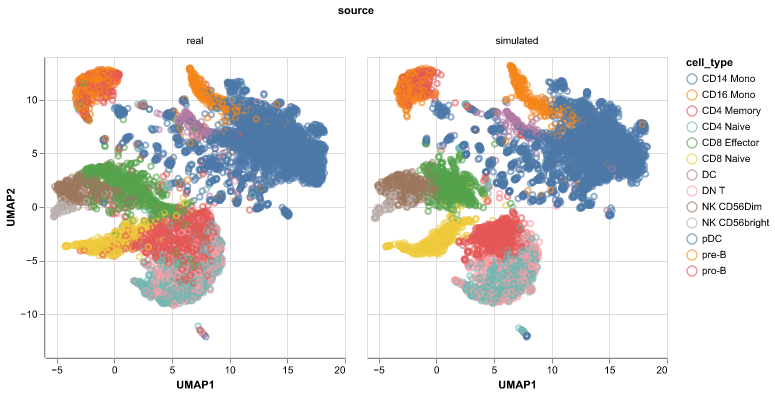

In [3]:
import numpy as np
from scdiagnostics import compare_umap
import altair
altair.renderers.enable('png')

def tf_idf(y):
    y_sum = np.sum(y, axis=0)
    nfreqs = np.divide(y, y_sum, where=y_sum != 0)
    nfreqs[np.isnan(nfreqs)] = 0

    idf = 1 + np.log1p(y.shape[1]) - np.log1p(np.sum(y > 0, axis=1))
    return nfreqs * idf[:, np.newaxis]

compare_umap(exper, samples, tf_idf, color="cell_type")